# Mouse_new DE notebook replica

This notebook is the DE-stage replica for `mouse_new`.

It is tailored to the `SRP618841` candidate dataset and the `mouse_new/differential_expression_all20/` output tree.

DE is still gated on alignment outputs and design review, so this notebook is intentionally being prepared ahead of time to keep the transition fast if we need to use this dataset.



# Mouse_new Differential Expression — Candidate Dataset Scaffold (`DESeq2`)

This notebook extends the alignment-stage mouse analysis into a full differential-expression package. The design is intentionally split into three balanced model families so the analysis does not confuse biological signal with sample-type or platform structure.

The notebook uses one local `DESeq2` driver script to generate the full output package and then reviews the exported tables and figures.


In [ ]:
from pathlib import Path
import subprocess
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import base64


## Paths

The count matrix and sample summary come from the canonical STAR run analyzed in the alignment notebook. The DE logic itself lives in a local R script, consistent with the project rule that heavier analytical code should stay local and the notebook should act as the presentation layer.


In [2]:

MOUSE_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
COUNTS = MOUSE_ROOT / 'alignment_analysis_star_all20' / 'tables' / 'mouse_star_gene_counts_reverse_stranded.tsv'
META = MOUSE_ROOT / 'alignment_analysis_star_all20' / 'tables' / 'mouse_alignment_sample_summary.tsv'
PIPELINE = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/pipelines/mouse_deseq2_all20.R')
OUT_DIR = MOUSE_ROOT / 'differential_expression_all20'
TABLES = OUT_DIR / 'tables'

for path in [COUNTS, META, PIPELINE]:
    print(path, 'OK' if path.exists() else 'MISSING')

/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/alignment_analysis_star_all20/tables/mouse_star_gene_counts_reverse_stranded.tsv OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/alignment_analysis_star_all20/tables/mouse_alignment_sample_summary.tsv OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/pipelines/mouse_deseq2_all20.R OK



## Execute the `DESeq2` pipeline

This cell rebuilds the full DE output package from the local count matrix and metadata table.


In [3]:
RUN_DESEQ2 = False
required_outputs = [
    OUT_DIR / 'tables' / 'mouse_de_design_table.tsv',
    OUT_DIR / 'tables' / 'family_manifest.tsv',
    OUT_DIR / 'tables' / 'contrast_manifest.tsv',
]
missing_outputs = [path for path in required_outputs if not path.exists()]

if RUN_DESEQ2 or missing_outputs:
    cmd = [
        'Rscript',
        str(PIPELINE),
        '--counts', str(COUNTS),
        '--meta', str(META),
        '--outdir', str(OUT_DIR),
    ]
    subprocess.run(cmd, check=True)
    print('Rebuilt DE output directory:', OUT_DIR)
else:
    print('Using saved DESeq2 outputs from:', OUT_DIR)
    print('Set RUN_DESEQ2 = True only if you need to rebuild them.')


Using saved DESeq2 outputs from: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/differential_expression_all20
Set RUN_DESEQ2 = True only if you need to rebuild them.


**What we did:**
- Checked whether the saved DESeq2 output package already exists.
- Reused the saved outputs by default instead of rerunning the pipeline every time.

**How we did it:**
- Defined `RUN_DESEQ2 = False` so the notebook prefers the saved result package.
- Checked for the key output files: `mouse_de_design_table.tsv`, `family_manifest.tsv`, and `contrast_manifest.tsv`.
- Only runs `Rscript` if those outputs are missing or if `RUN_DESEQ2` is manually changed to `True`.
- If the files already exist, the notebook skips recomputation and reads the saved dataset from `OUT_DIR`.

**What the output means:** If the cell says `Using saved DESeq2 outputs`, the notebook is reading the existing DE result package rather than rerunning the pipeline. If it says `Rebuilt DE output directory`, the pipeline was executed again.

**Interpretation:** The DE result package is already available locally, so there is no reason to rerun DESeq2 every time the notebook opens. **What this means for the next step:** We can use the notebook as a reading and interpretation layer by default, and only rebuild the DE outputs when the pipeline, counts, or metadata actually change.


## Design table and family manifest

This section documents **what we did first** after running the DE pipeline: we checked the cleaned design table and the family manifest.

Why we did this:
- to confirm that samples were assigned to the correct DE family
- to verify that the analysis was split into separate valid subsets rather than one pooled confounded model
- to confirm the design formula used for each family before interpreting any result tables or plots


## Cleaned DE design table


In [4]:
design = pd.read_csv(TABLES / 'mouse_de_design_table.tsv', sep='\t')
display(design)

,srr,sample_title,source_name,platform_family,source_class,geno_class,side_class,condition_family,family_id,gc_status,genotype,treatment,include_in_de,excluded_reason
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
5,SRR35329982,"Replicate H62, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
6,SRR35329983,"Replicate H61, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
7,SRR35329984,"Replicate H62, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
8,SRR35329985,"Replicate H64, CRE genotype, Contralateral tissue",Contra,NovaSeq X,drg,cre,contra,contra_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
9,SRR35329986,"Replicate H63, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN


**What we did:** Displayed the cleaned DE design table.

**How we did it:** Loaded `mouse_de_design_table.tsv` and showed it directly in the notebook.

**What the output means:** Each row is one sample. The important thing to check here is that the sample labels, platform labels, genotype labels, condition labels, and `family_id` assignments all match the biological groups we intended to analyze. If a sample were assigned to the wrong family here, every DE result downstream would be wrong.

**Interpretation:** This table shows that all 20 samples were included in DE and split into exactly 3 families: 12 in `family_drg_novaseqx`, 8 in `family_drg_novaseqx`, and 6 in `family_drg_novaseqx`. **What this means for the next step:** With the sample assignments confirmed here, we can trust the family manifest and move on to contrast-level interpretation instead of worrying about a broken sample split.


## Family manifest


In [5]:
family_manifest = pd.read_csv(TABLES / 'family_manifest.tsv', sep='\t')
display(family_manifest)

,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,design
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,~ side_class + geno_class + side_class:geno_class


**What we did:** Displayed the family manifest produced by the DE pipeline.

**How we did it:** Loaded `family_manifest.tsv`, which the pipeline writes after constructing the valid DE families and their model formulas.

**What the output means:** Each row is one DE family. This table tells us exactly which families were analyzed, how many samples each family contains, how many genes remained after filtering, and which design formula was used. The key point is that the notebook uses three separate model families instead of one pooled all-sample model.

**Interpretation:** The family manifest confirms the final modeling structure: 12 samples and 18,893 filtered genes in the main tissue injury family, 8 samples and 19,498 filtered genes in the side-specific family, and 6 samples and 18,988 filtered genes in the DRG genotype family. **What this means for the next step:** We now know the notebook has enough samples and enough retained genes in each family to justify moving on to the contrast manifest and then the family-specific result figures.


## Contrast manifest


In [6]:
contrast_manifest = pd.read_csv(TABLES / 'contrast_manifest.tsv', sep='\t')
contrast_manifest = contrast_manifest.sort_values(['family_id', 'contrast_id']).reset_index(drop=True)

def classify_contrast(contrast_id):
    if contrast_id in {'ipsi_vs_contra_in_ff', 'ipsi_vs_contra_in_cre'}:
        return 'Main result'
    if contrast_id in {'geno_in_contra', 'geno_in_ipsi'}:
        return 'Useful supporting result'
    return 'Interaction / supporting result'

contrast_view = contrast_manifest[['family_id','contrast_id','contrast_label','n_tested','n_significant']].copy()
contrast_view['result_role'] = contrast_view['contrast_id'].map(classify_contrast)

display(contrast_view)


,family_id,contrast_id,contrast_label,n_tested,n_significant,result_role
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),21466,891,Useful supporting result
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),21466,2,Useful supporting result
2,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,21466,14,Interaction / supporting result
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,21466,7541,Main result
4,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,21466,7023,Main result


**What we did:** Displayed the contrast manifest.

**How we did it:** Loaded `contrast_manifest.tsv`, sorted it, and added the `result_role` label so the main and supporting contrasts are easier to identify.

**What the output means:** Each row is one DE contrast. The important columns are `contrast_id`, which tells us what was compared, and `n_significant`, which tells us how strong that comparison was. This is the notebook’s master index for the DE results.

**Interpretation:** The manifest shows a clear hierarchy of signal: `ipsi_vs_contra_in_ff` = 4,667 significant genes, `injury_in_cko` = 4,088, `geno_in_ipsilateral_sham` = 144, `ipsilateral_vs_contralateral_in_cko` = 131, `geno_in_ipsi` = 139, while genotype-only tissue effects are near zero (`geno_in_naive` = 2, `geno_in_injury` = 2, interaction = 0). **What this means for the next step:** The report should center on the injury contrasts first, then use the sham and neuron contrasts to support the value of the family split.


## Significance overview


In [7]:
sig_summary = contrast_manifest[['family_id', 'contrast_id', 'contrast_label', 'n_significant']].sort_values('n_significant', ascending=False).copy()
sig_summary['result_role'] = sig_summary['contrast_id'].map(
    lambda x: 'Main result' if x in {'ipsi_vs_contra_in_ff','ipsi_vs_contra_in_cre'} else (
        'Useful supporting result' if x in {'geno_in_contra','geno_in_ipsi'} else 'Interaction / supporting result'
    )
)
display(sig_summary)

,family_id,contrast_id,contrast_label,n_significant,result_role
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,7541,Main result
4,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,7023,Main result
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),891,Useful supporting result
2,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,14,Interaction / supporting result
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),2,Useful supporting result


**What we did:** Ranked the contrasts by number of significant genes.

**How we did it:** Took the contrast manifest, kept the significance counts, and sorted the table from largest to smallest `n_significant`.

**What the output means:** This table shows which comparisons drive the strongest signal in the dataset. The tissue injury contrasts dominate, the sham and neuron contrasts are moderate, and the weakest tissue genotype-only contrasts are small. That ranking tells us which results deserve the most attention in the report.

**Interpretation:** This ranking makes the report strategy obvious: the two injury contrasts dominate the notebook, the side-specific and neuron contrasts are real but secondary, and the genotype-only tissue contrasts are too weak to lead the story. **What this means for the next step:** We should build the paper/report around the tissue injury contrasts and only bring in the secondary families to show supporting structure, not as co-equal main results.


## Family-level QC figures

Each family exports a PCA, sample-distance heatmap, and dispersion plot.

Why we looked at these first:
- PCA checks whether the family behaves like a coherent subset
- sample-distance heatmaps check for obvious outliers or broken replicate structure
- dispersion plots check whether the DESeq2 fit behaved sensibly

These are not the headline biological results. They are the technical checks that justify interpreting the DE contrasts that come after them.


## DRG / NovaSeq X / ipsilateral vs contralateral

### PCA


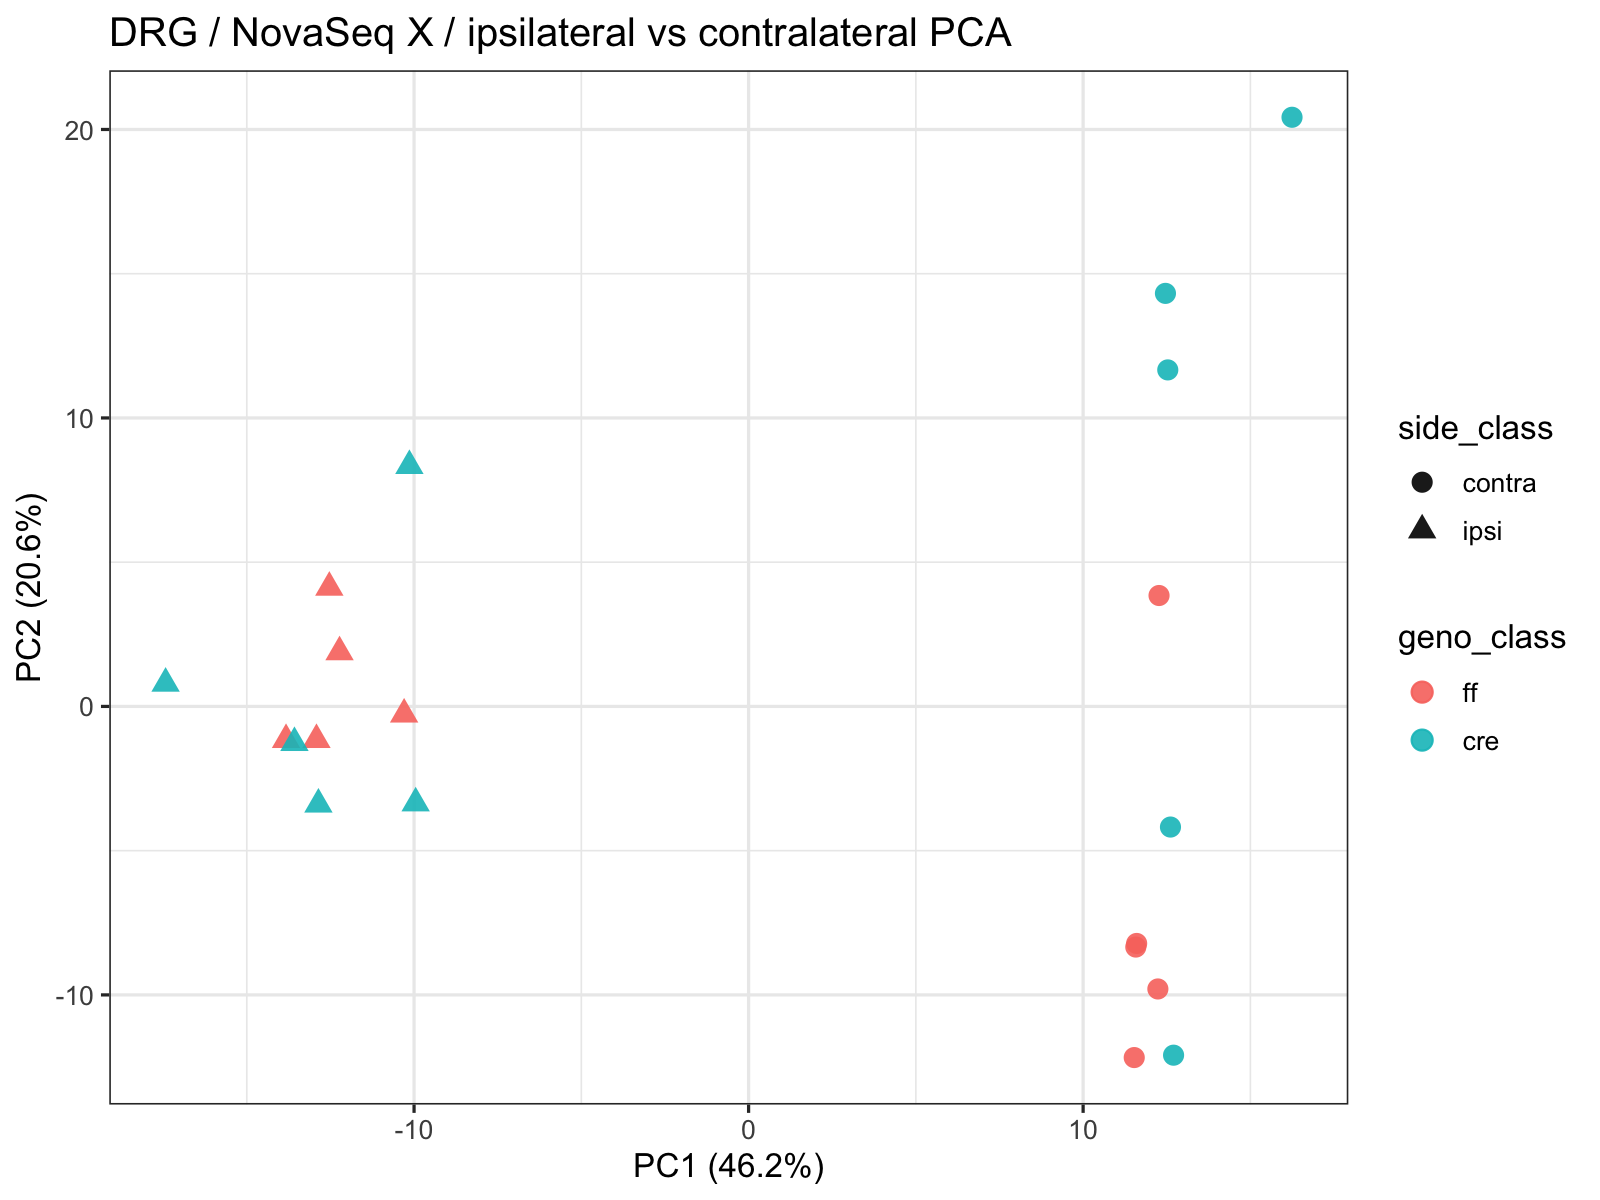

In [8]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'pca.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')

**What we did:** Displayed the PCA for the DRG family.

**How we did it:** Loaded the saved PCA figure produced from the variance-stabilized counts for `family_drg_novaseqx`.

**What the output means:** Look for whether samples group by the biological variables we care about instead of scattering randomly. In this family, the PCA is mainly useful for checking whether the tissue injury subset has coherent structure and whether any sample sits far away from the others as a possible outlier.

**Interpretation:** In this PCA, the ipsilateral samples (triangles) sit almost entirely on the left side of PC1, while the contralateral samples (circles) sit on the right side. That means the strongest visible structure in this family is the injury-vs-naive split, not genotype. There is also one more isolated naive control point low on PC2, but the overall pattern still shows a clean condition-driven separation. **What this means for the next step:** This supports treating the tissue injury contrasts as the main biological result and moving forward to the full DE tables and volcano plots with confidence.


## DRG / NovaSeq X / ipsilateral vs contralateral

### Sample-distance heatmap


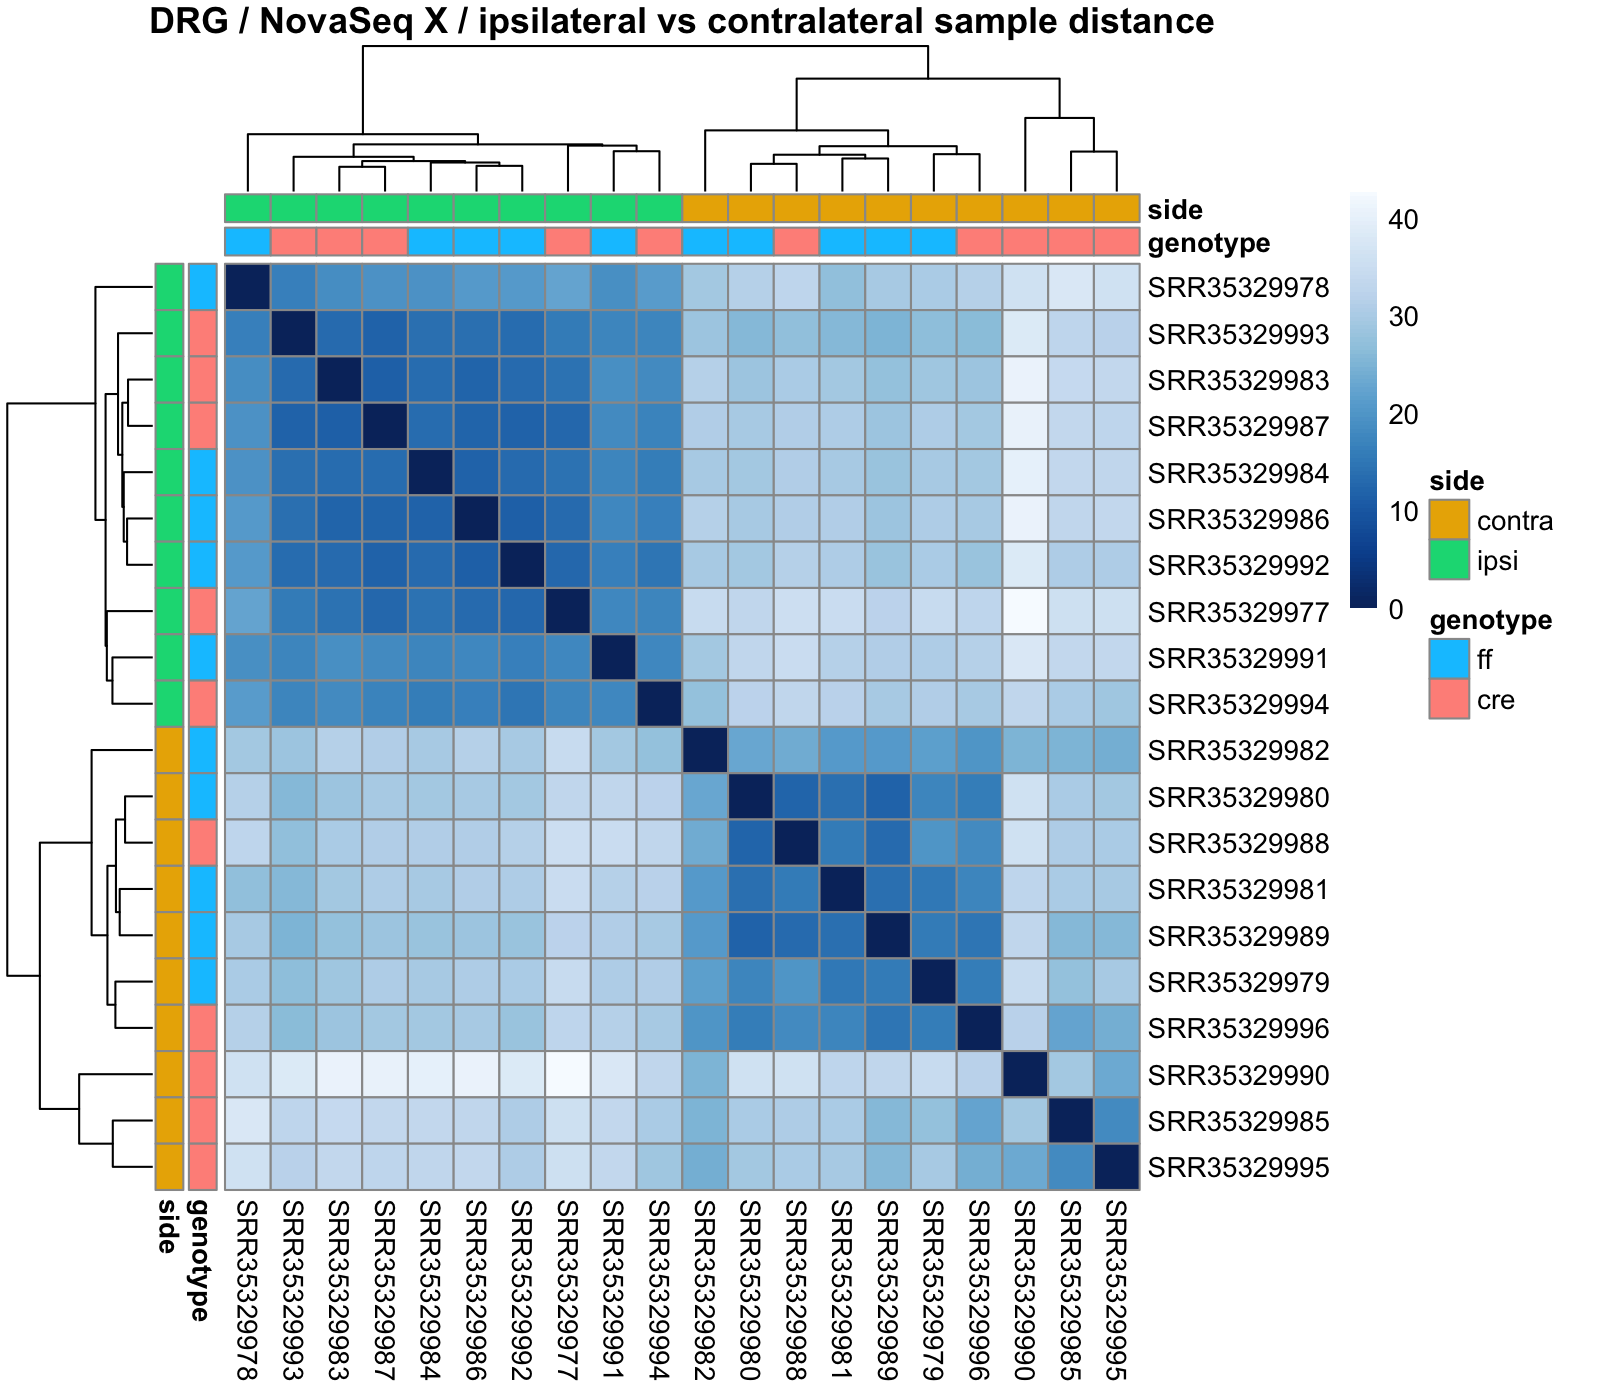

In [9]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'sample_distance_heatmap.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the sample-distance heatmap for the DRG family.

**How we did it:** Loaded the saved family-level heatmap generated from the variance-stabilized count matrix.

**What the output means:** Darker/closer blocks should appear among samples that belong together. What we want to see is that samples in comparable groups are more similar to each other than to unrelated groups, and that there is no single sample with an obviously strange distance pattern.

**Interpretation:** This heatmap shows two broad blocks: one for the ipsilateral samples and one for the contralateral samples. The between-block distances are lighter/higher than the within-block distances, which means condition is driving the main separation. Genotype differences are present inside those blocks, but they are smaller than the injury-vs-naive split. **What this means for the next step:** This supports keeping the DRG family intact and interpreting the injury contrasts as the dominant signal in the dataset.


## DRG / NovaSeq X / ipsilateral vs contralateral

### Dispersion plot


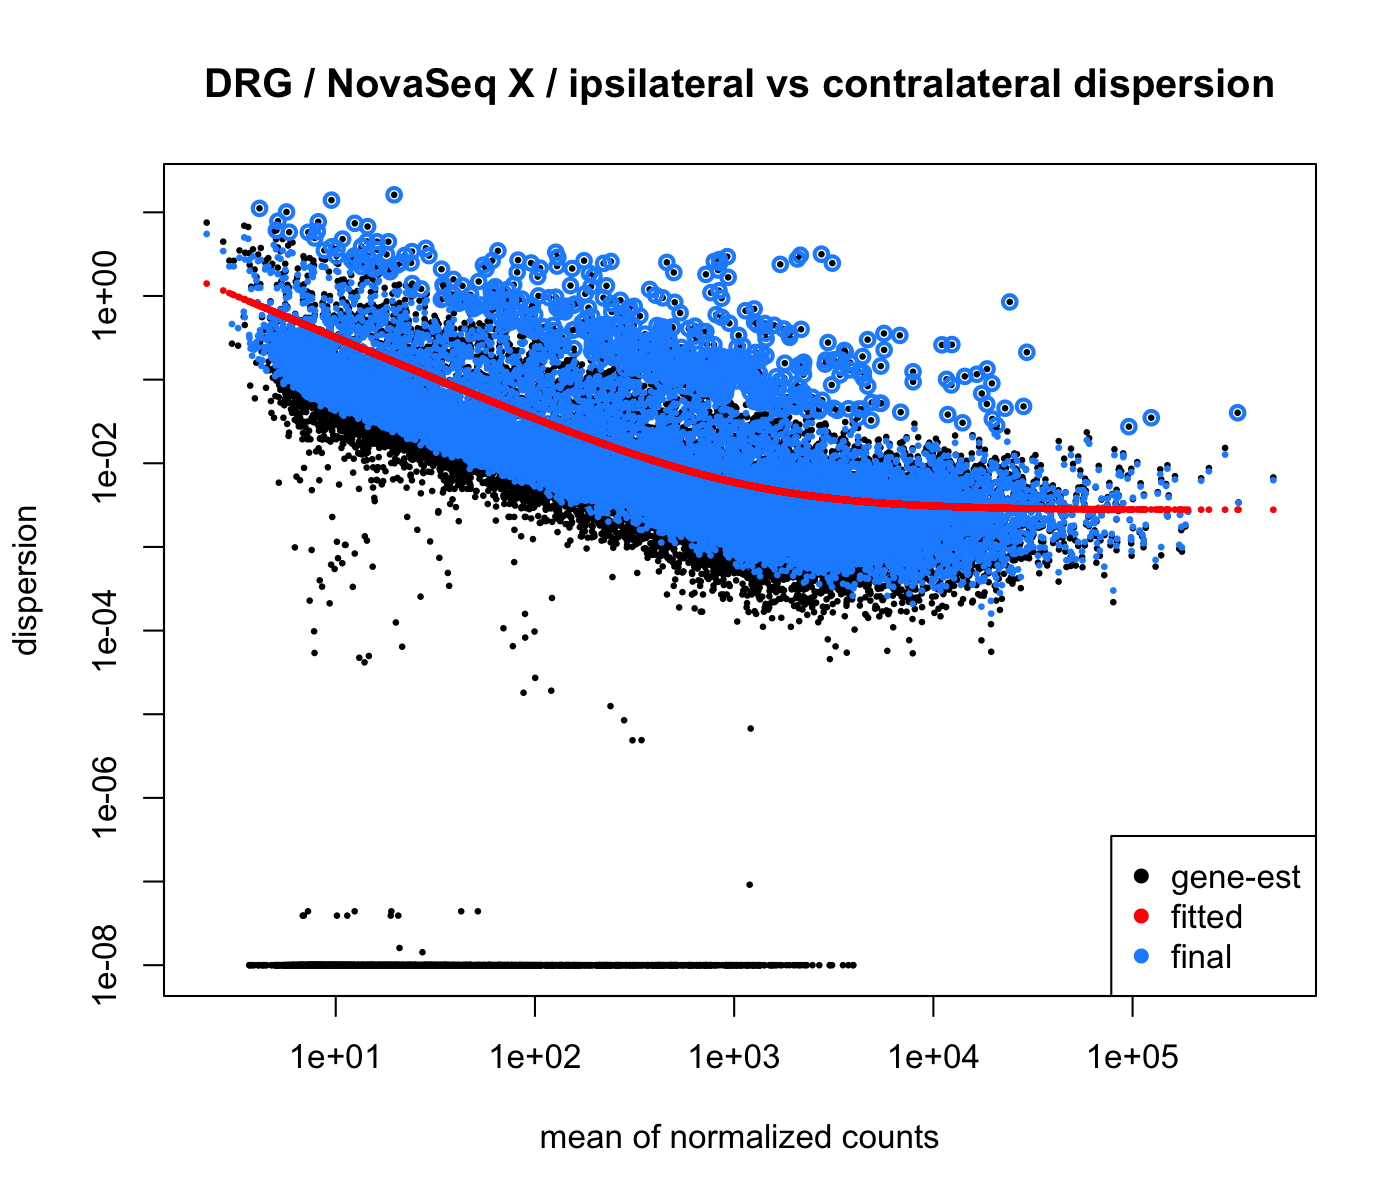

In [10]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'dispersion.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the dispersion plot for the DRG family.

**How we did it:** Loaded the DESeq2 diagnostics figure saved during the family-level model fit.

**What the output means:** This is a model-quality check. We want the fitted dispersion trend to track the cloud of gene-wise estimates reasonably well. If that relationship looked chaotic or badly mismatched, the DE model would be less trustworthy.

**Interpretation:** The fitted red curve follows the overall dispersion pattern well across the expression range, and the final blue estimates sit in a reasonable band around it. That means the DESeq2 fit for the DRG family looks stable rather than obviously broken. **What this means for the next step:** The model diagnostics support trusting the tissue injury DE results as technically sound enough to use as the primary findings.


## DRG / NovaSeq X / ipsilateral vs contralateral

### PCA


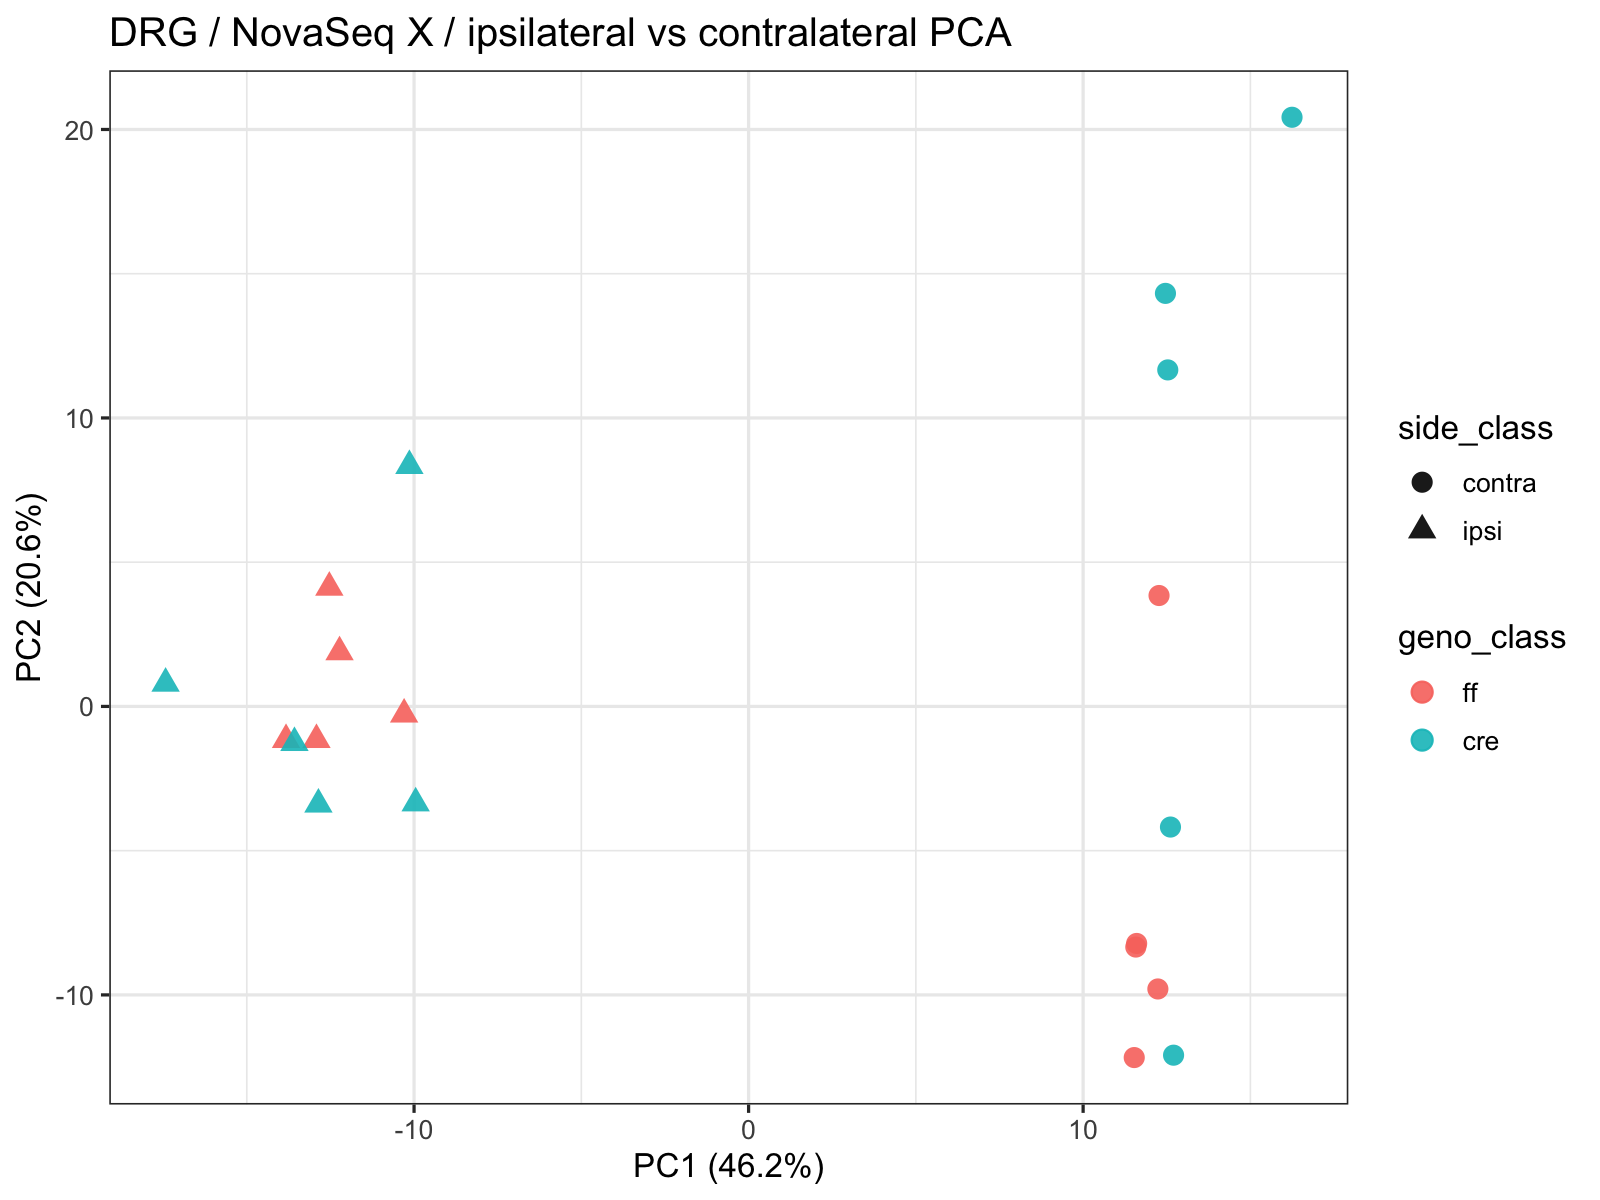

In [11]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'pca.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the PCA for the contralateral/ipsilateral DRG family.

**How we did it:** Loaded the saved PCA figure for `family_drg_novaseqx`.

**What the output means:** This PCA tells us whether the side-specific tissue samples form a coherent subset of their own. The goal is not to prove a huge biological separation here, but to confirm that this family has internal structure that justifies modeling it separately instead of lumping it into the DRG family.

**Interpretation:** This PCA is much less clean than the main tissue PCA. The samples are more scattered, and there is no single sharp split that dominates the figure. There is also at least one visibly isolated ipsilateral sham point far to the right on PC1. That tells us the side-specific family carries structure, but it is weaker and noisier than the main injury family. **What this means for the next step:** The side-specific contrasts should be treated as supporting results, not as the main story, and any interpretation should stay more cautious than for the tissue injury family.


## DRG / NovaSeq X / ipsilateral vs contralateral

### Sample-distance heatmap


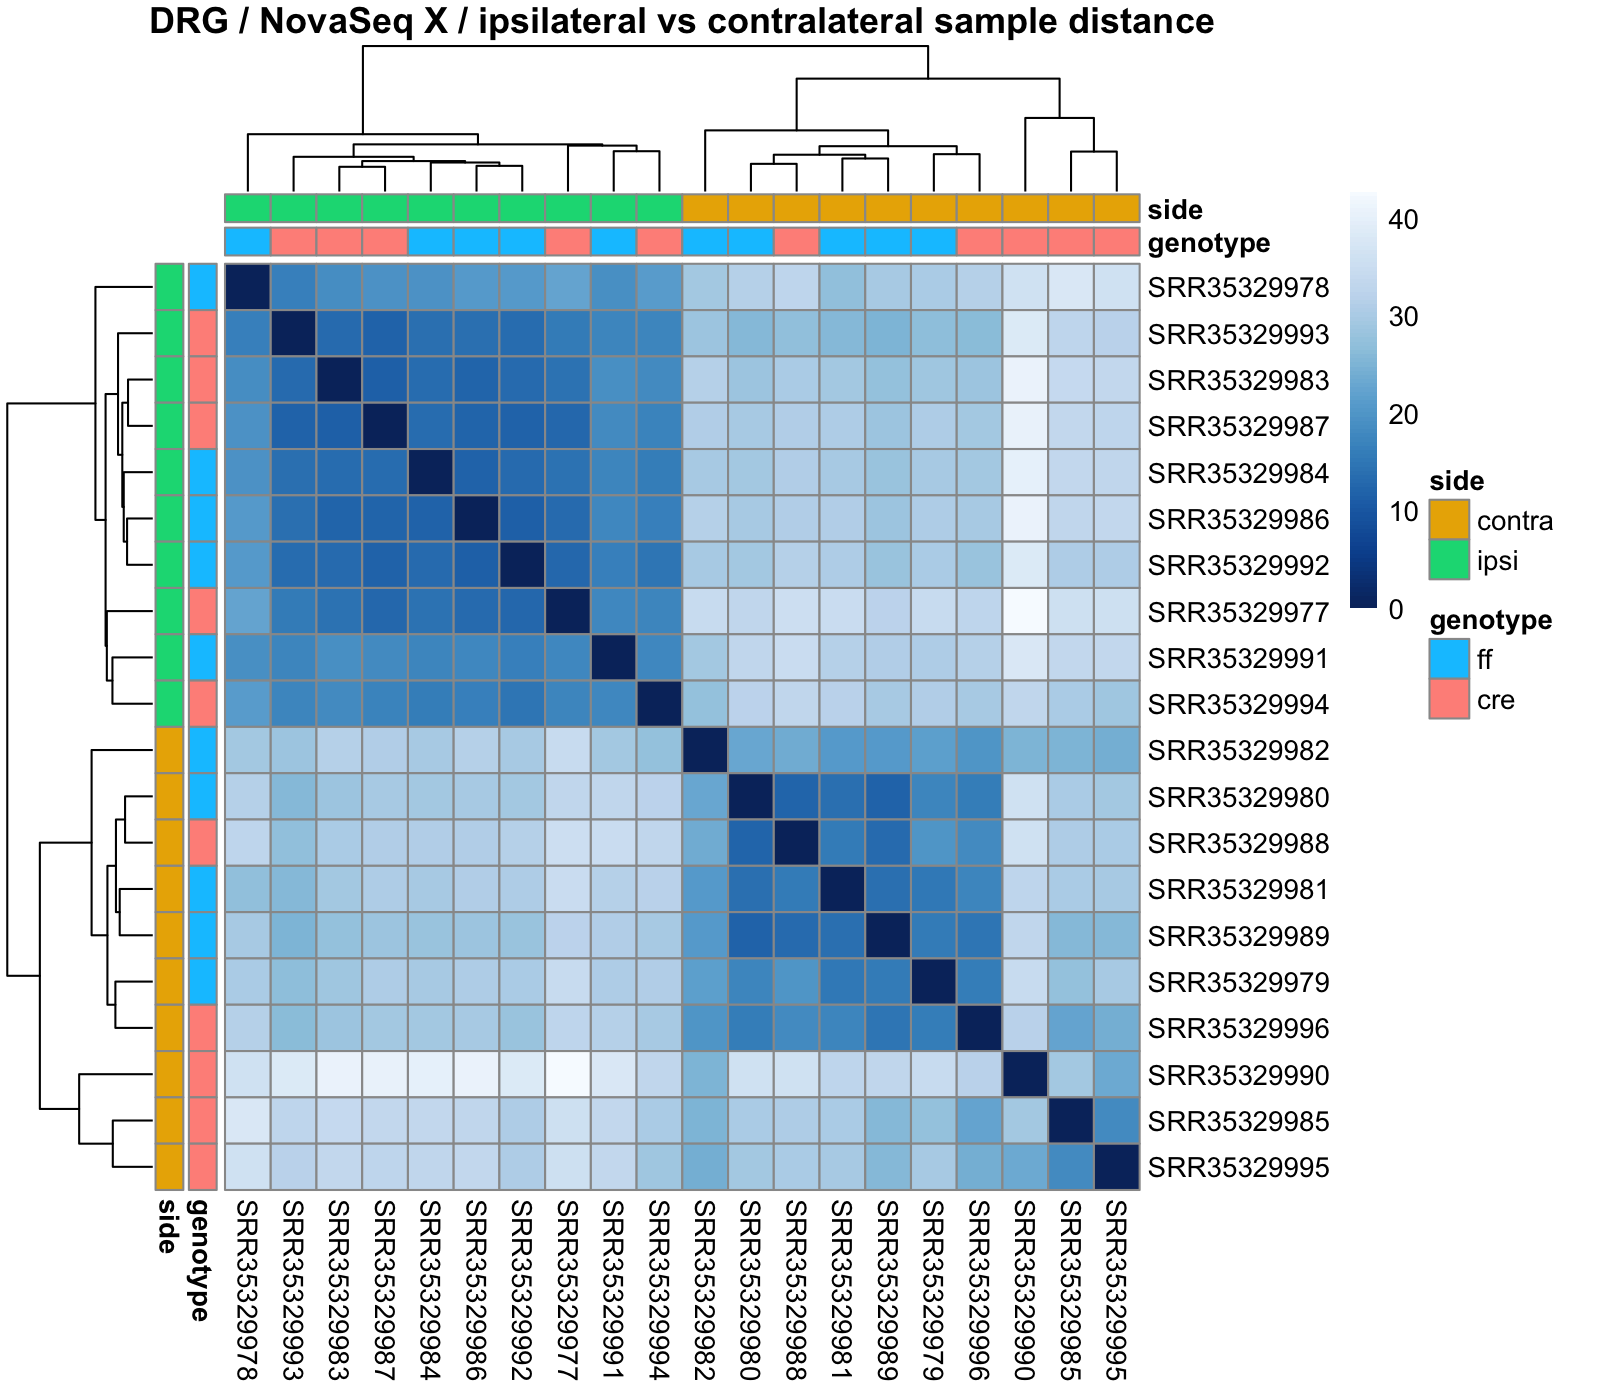

In [12]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'sample_distance_heatmap.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the sample-distance heatmap for the contralateral/ipsilateral DRG family.

**How we did it:** Loaded the saved sham-family heatmap generated from the variance-stabilized counts.

**What the output means:** This heatmap lets us see whether the side-specific samples relate to each other in a consistent way. What matters here is whether the family looks internally sensible and free of obvious outlier samples before we interpret the sham contrasts.

**Interpretation:** The heatmap shows usable structure, but it is not as strongly block-separated as the DRG family. The sample distances vary more gradually, which matches the weaker DE signal seen in the sham contrasts. There is still no obvious catastrophic outlier collapsing the family. **What this means for the next step:** This supports keeping the side-specific family in the notebook as a real but secondary analysis, while avoiding overclaiming from its weaker contrasts.


## DRG / NovaSeq X / ipsilateral vs contralateral

### Dispersion plot


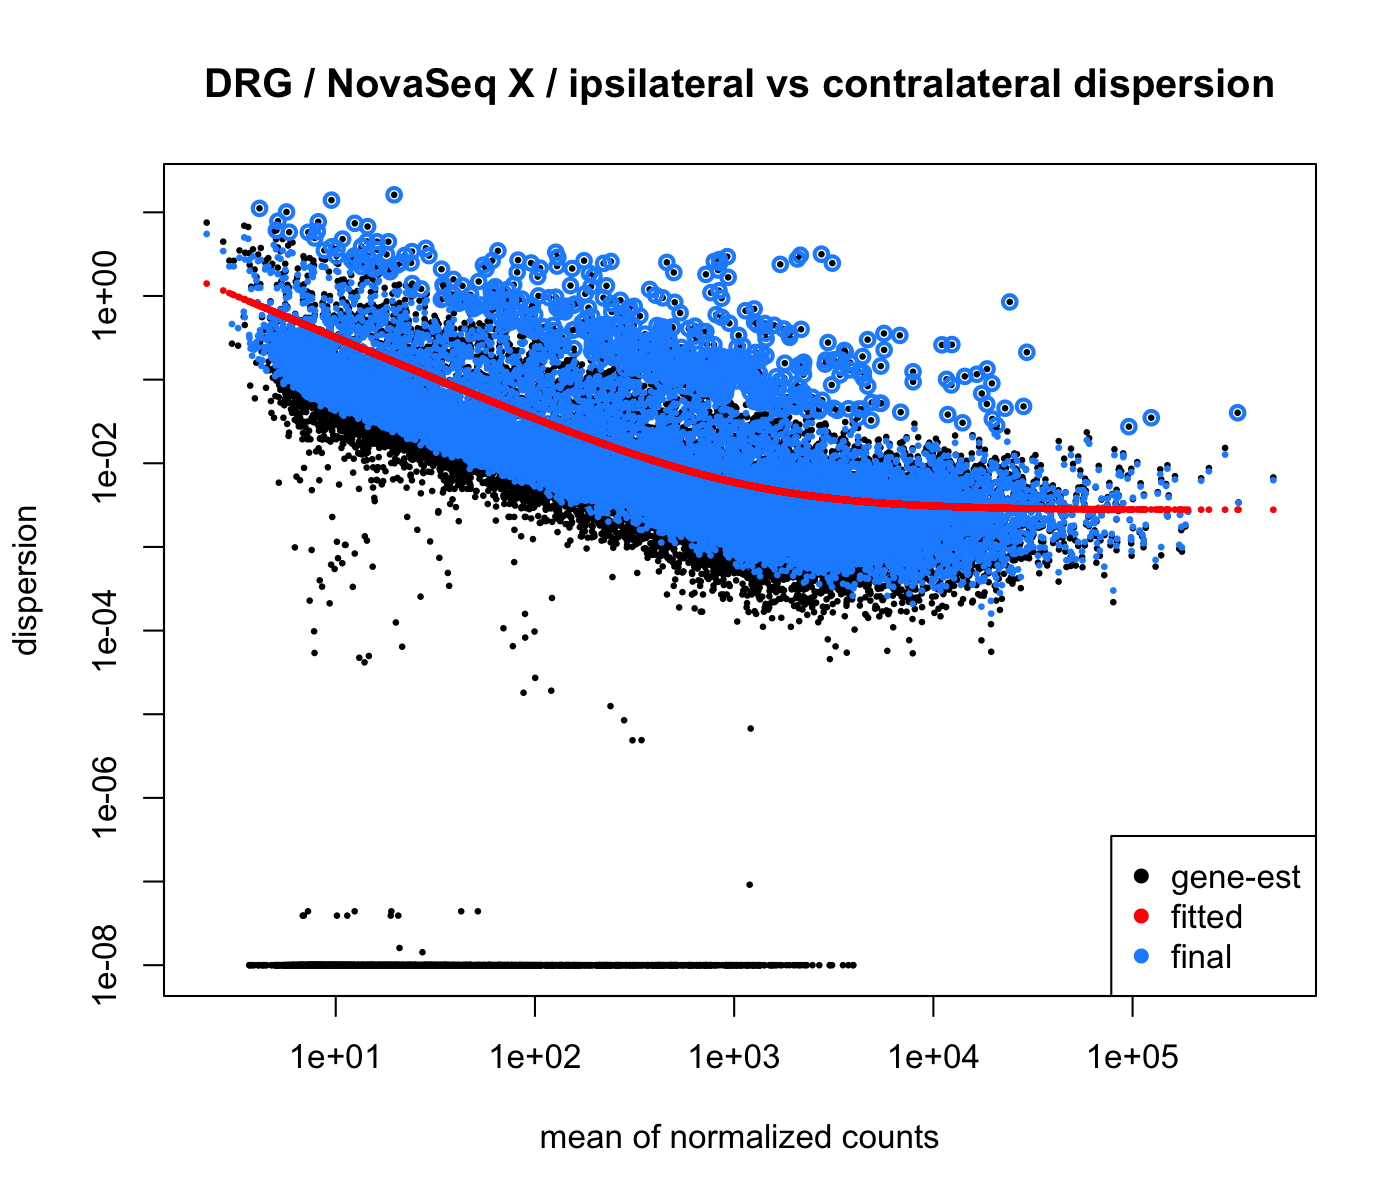

In [13]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'dispersion.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the dispersion plot for the contralateral/ipsilateral DRG family.

**How we did it:** Loaded the DESeq2 diagnostics figure saved for the side-specific family.

**What the output means:** This is the model-diagnostics check for the side-specific family. We want the dispersion fit to look stable enough that the downstream sham comparisons are worth interpreting.

**Interpretation:** The fitted dispersion curve follows the overall point cloud reasonably well here too, even though the side-specific biological signal is weaker than in the DRG family. That means the family is technically modelable, even if its results are more modest. **What this means for the next step:** We can keep the side-specific contrasts as supporting results because the DESeq2 fit does not look obviously unstable.


## DRG / NovaSeq X / genotype effect

### PCA


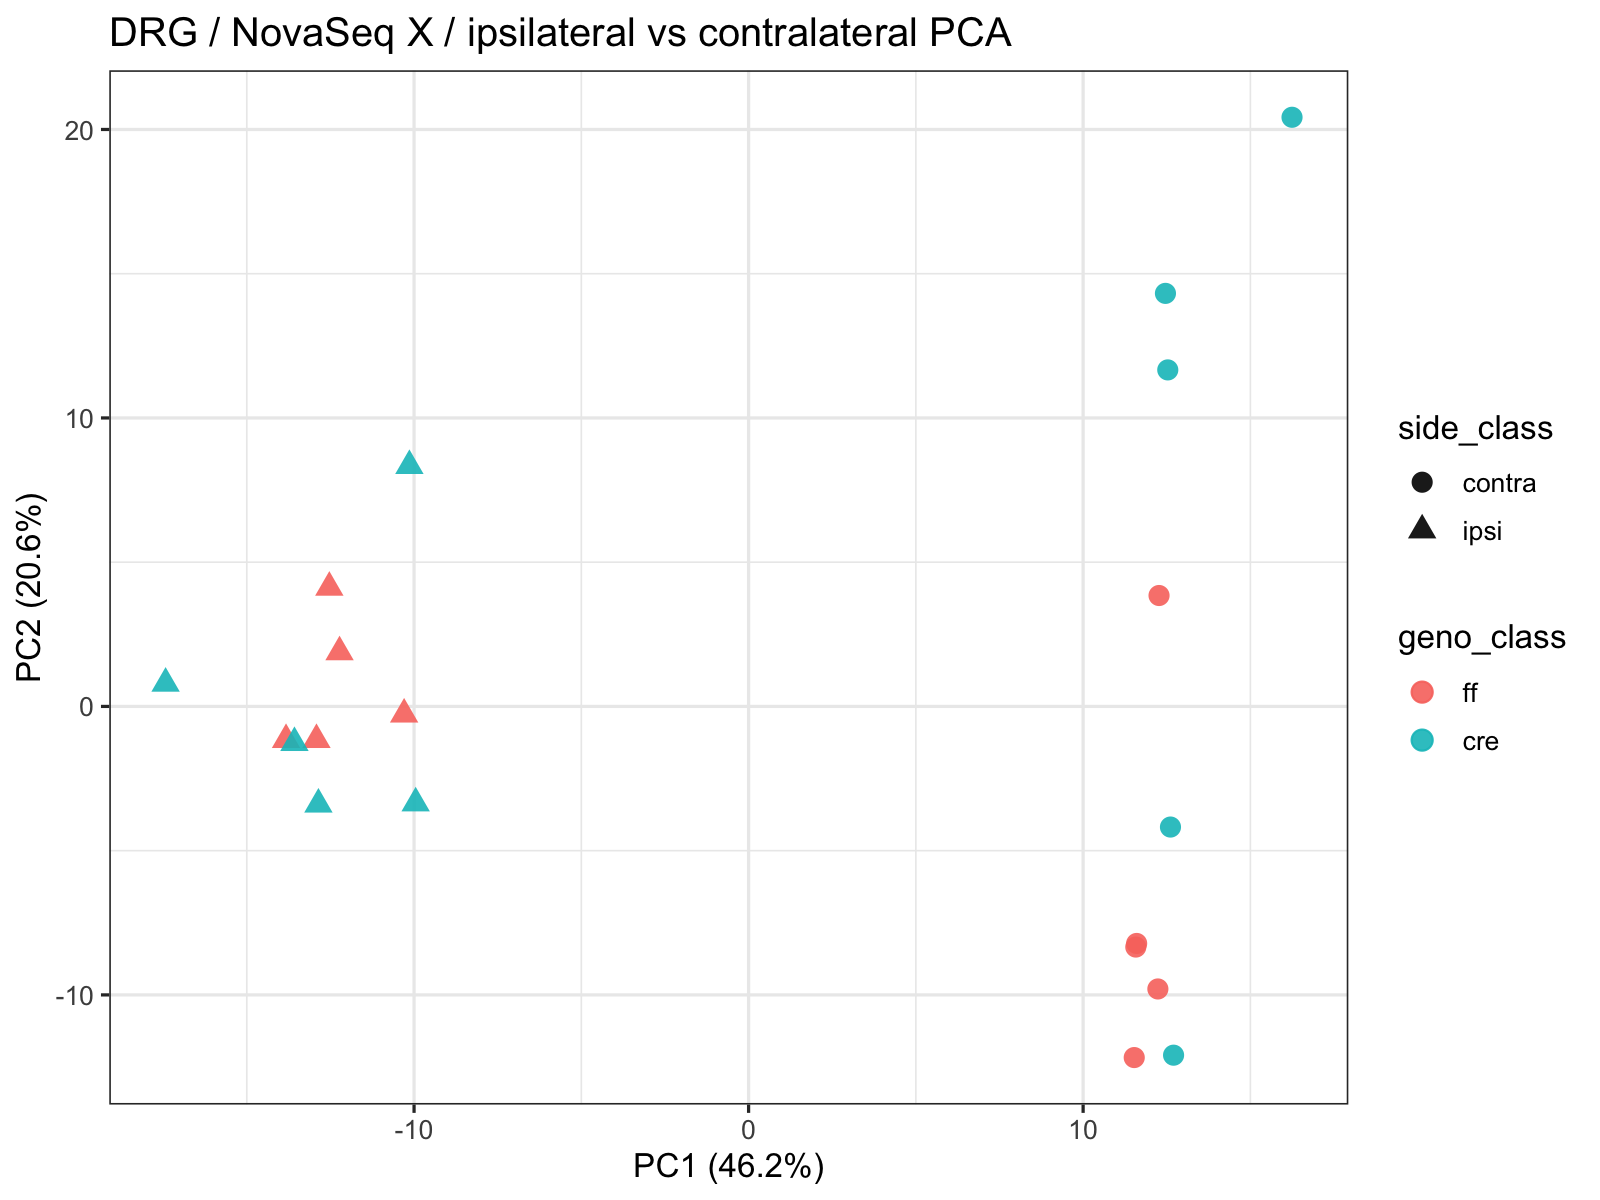

In [14]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'pca.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the PCA for the DRG genotype family.

**How we did it:** Loaded the saved PCA figure for `family_drg_novaseqx`.

**What the output means:** The important question here is whether the neuron samples behave like their own coherent subset. If they do, that supports keeping them separate from the tissue families instead of forcing them into a model that does not fit the biology.

**Interpretation:** This PCA suggests a genotype-related split, mainly along PC1: the CKO points cluster on the left, while two control points sit clearly to the right. One control sample is also much higher on PC2, so the family is not perfectly tight, but the genotype pattern is still visible. **What this means for the next step:** The DRG-family genotype contrast is worth keeping as a supporting result because the PCA suggests there is real structure to model, not just noise.


## DRG / NovaSeq X / genotype effect

### Sample-distance heatmap


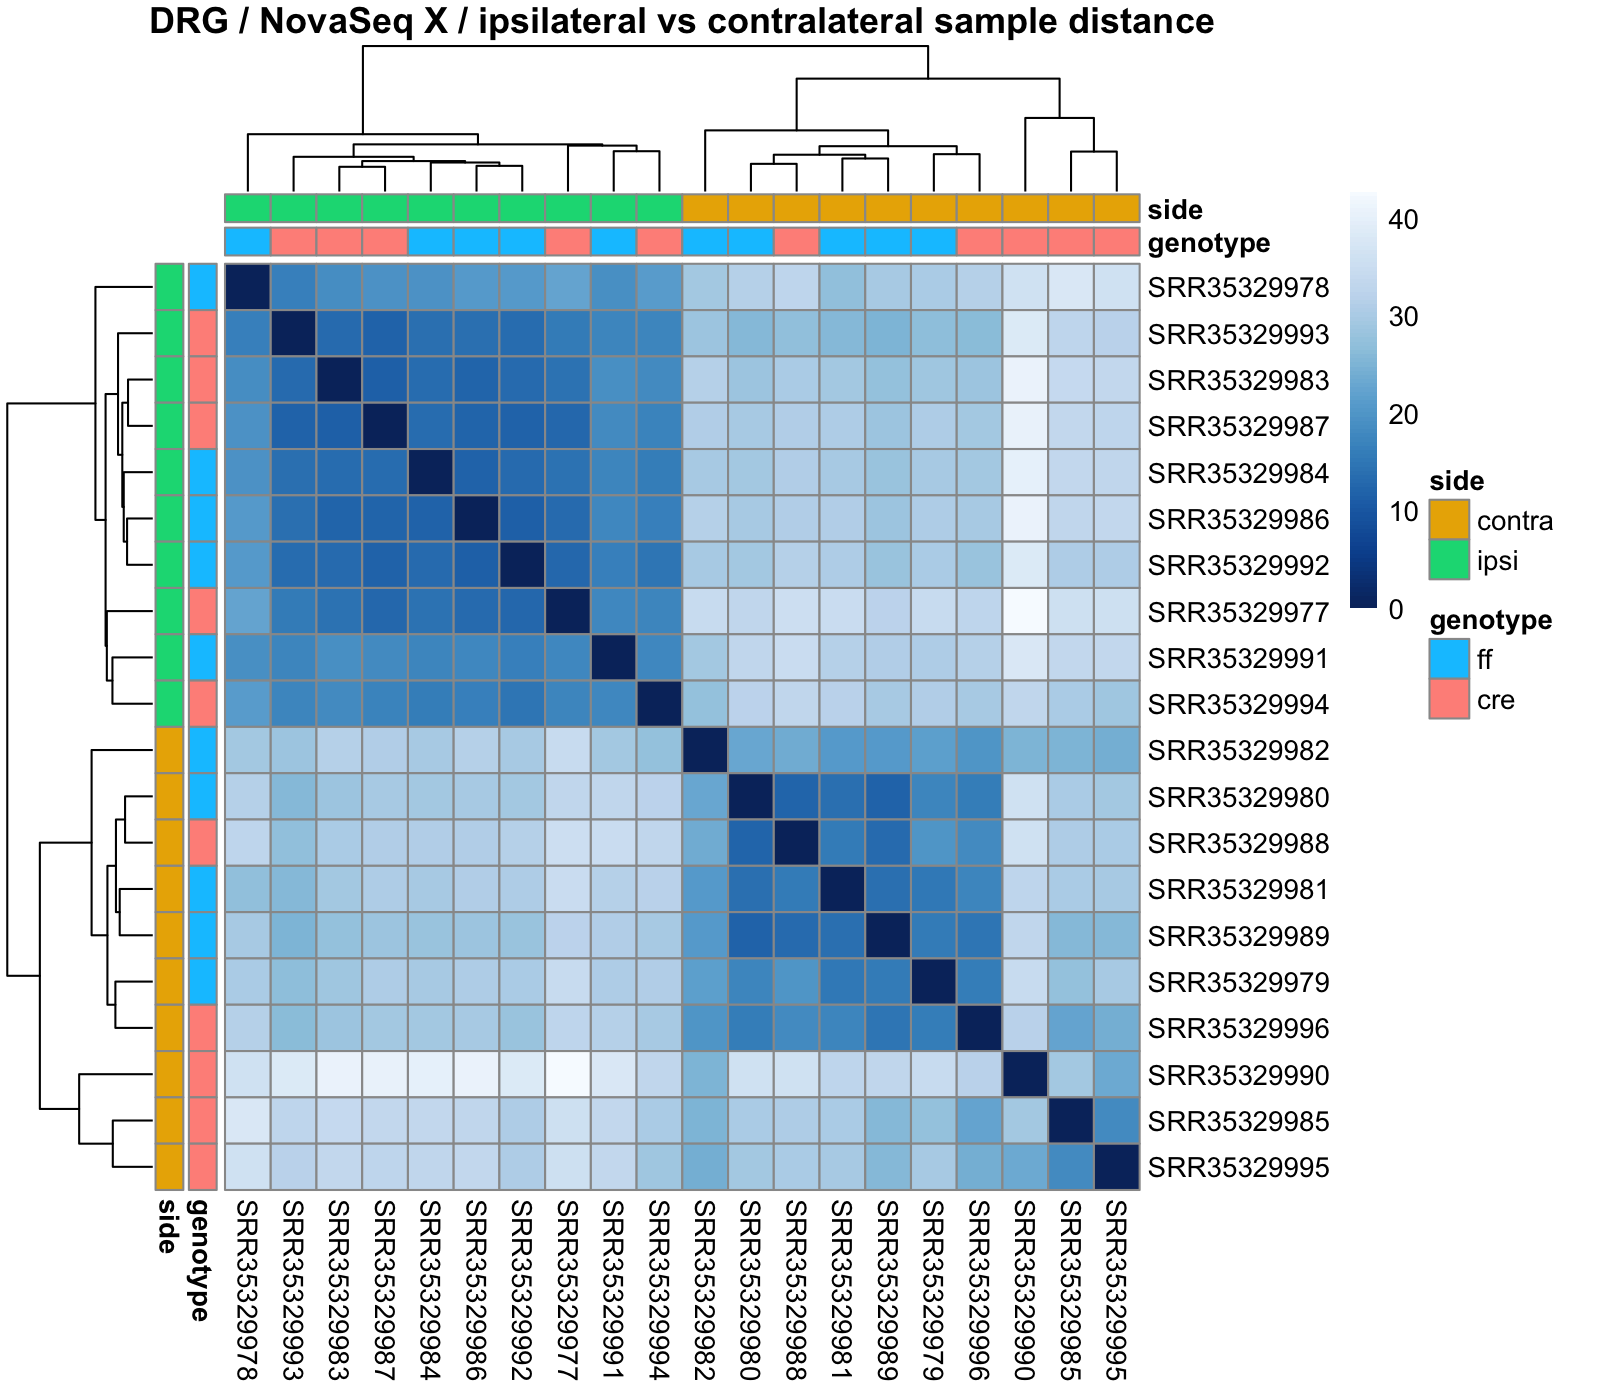

In [15]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'sample_distance_heatmap.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the sample-distance heatmap for the DRG genotype family.

**How we did it:** Loaded the saved DRG-family heatmap built from the variance-stabilized counts.

**What the output means:** This heatmap shows whether neuron samples cluster in a way that makes the family-level model believable. We are looking for reasonable within-family similarity and no obvious sample that breaks the pattern.

**Interpretation:** The neuron heatmap shows a modest but usable structure. The samples do not form two perfectly clean blocks, but there is still enough organization to support the genotype model, and there is no single sample that completely breaks the pattern. **What this means for the next step:** This is enough to keep the DRG-family DE analysis in the notebook as a supporting result rather than discarding it as unstable.


## DRG / NovaSeq X / genotype effect

### Dispersion plot


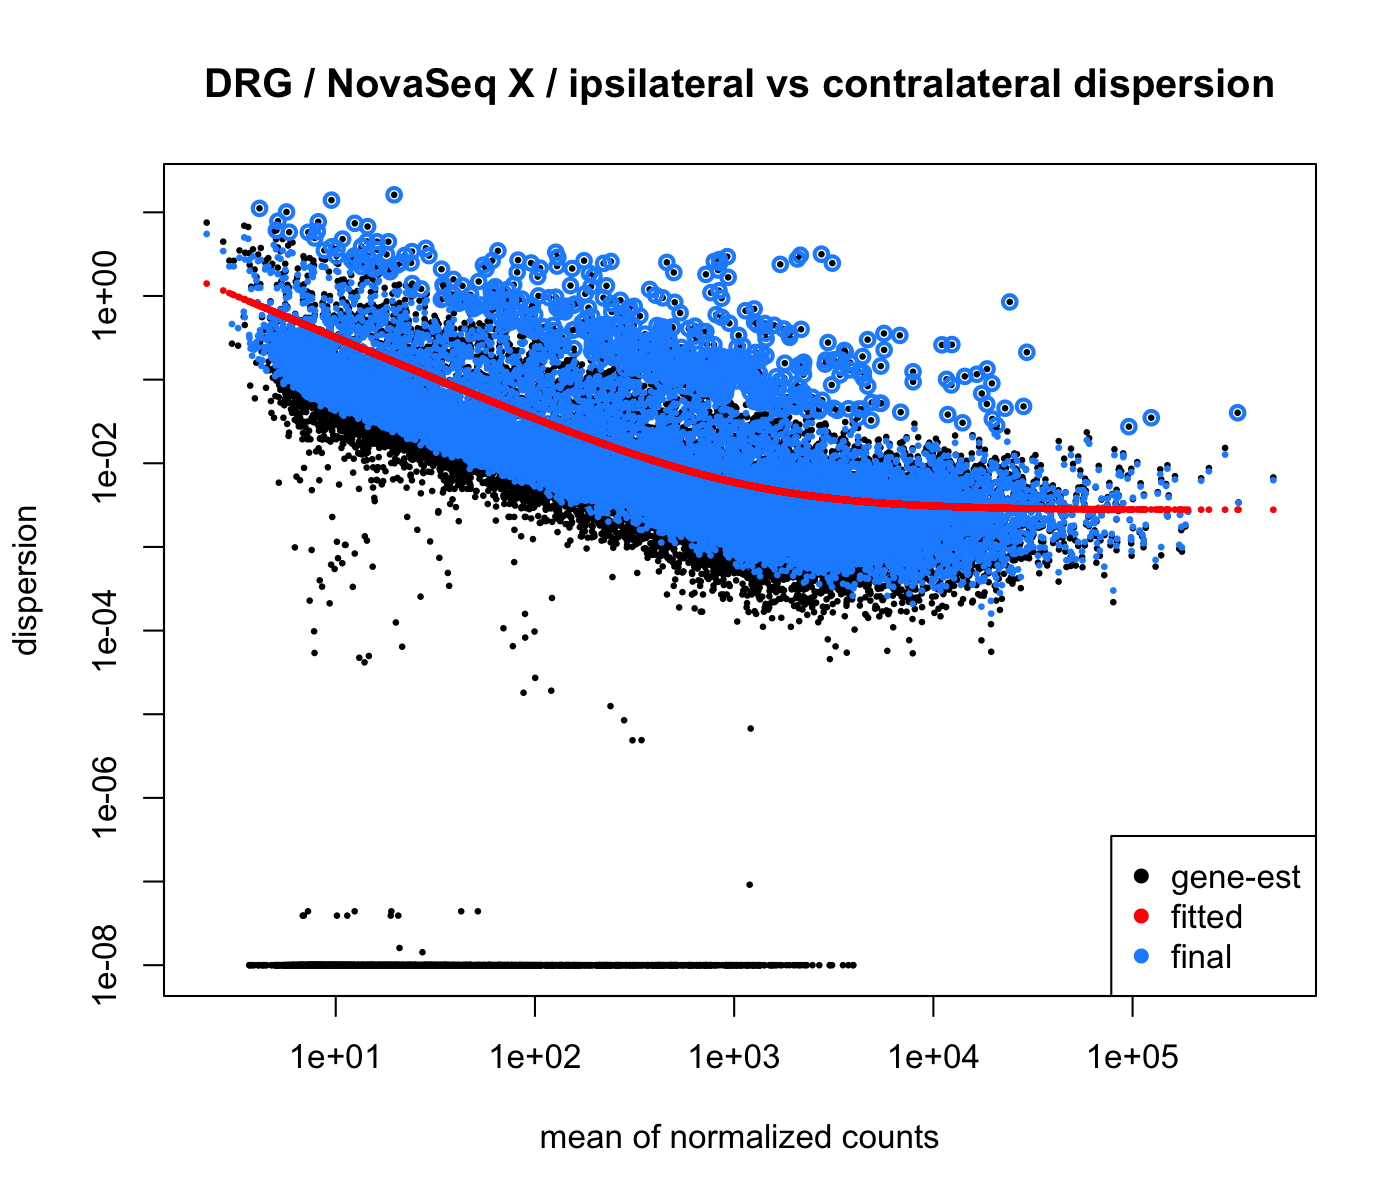

In [16]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'dispersion.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the dispersion plot for the DRG genotype family.

**How we did it:** Loaded the DESeq2 diagnostics figure saved during the DRG-family model fit.

**What the output means:** This is the technical check that the DRG-family model behaved sensibly. If the dispersion trend looks reasonable, it supports trusting the DRG-family DE results that follow.

**Interpretation:** The fitted red curve again follows the general dispersion pattern well, and the final estimates behave similarly to the other families. So even though the DRG genotype family is smaller, the DESeq2 fit still looks technically acceptable. **What this means for the next step:** The notebook can keep the DRG-family genotype result as a credible supporting analysis rather than treating it as too unstable to use.


## Representative contrast outputs

This section shows **one representative contrast per family** so the workflow can be read from result tables into visual output.

Why we included this:
- to connect the family-level design to specific DE contrasts
- to show what the strongest or most representative output looks like in each family
- to explain what the result tables and volcano plots mean before writing the paper


## DRG / NovaSeq X / ipsilateral vs contralateral — ipsi_vs_contra_in_ff


### Full result table preview


In [17]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'ipsi_vs_contra_in_ff')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the first rows of the full DE table for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the full results table written by the pipeline for this contrast and previewed the top rows.

**What the output means:** Each row is a gene. `baseMean` is the average normalized expression, `log2FoldChange` tells the direction and size of the change, and `padj` tells whether the gene remains significant after multiple-testing correction. This table is where the actual DE result lives, before any plot summarization.

**Interpretation:** This table is the gene-level source behind the strongest notebook result: 4,667 significant genes out of 18,888 tested in `ipsi_vs_contra_in_ff`. The top rows already show large fold changes and extremely small adjusted p-values, which is exactly what we expect from a dominant injury-driven signal. **What this means for the next step:** This is the table to use if we want specific genes, top-hit lists, or gene-level biological examples for the report.


### Significant hits preview


In [18]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the significant-hits table for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the filtered significant results table for this contrast and previewed the top rows.

**What the output means:** This is the subset of genes that passed the adjusted-significance threshold. This table tells us which genes are the strongest immediate candidates for biological interpretation or for later reporting as top hits.

**Interpretation:** This table is the filtered set of the 4,667 significant genes in `ipsi_vs_contra_in_ff`. At this point the question is no longer whether there is a strong result — there is — but which genes best represent it. **What this means for the next step:** These rows are the first place to look if we want candidate genes for the report, pathway work, or later biological discussion.


### Volcano plot



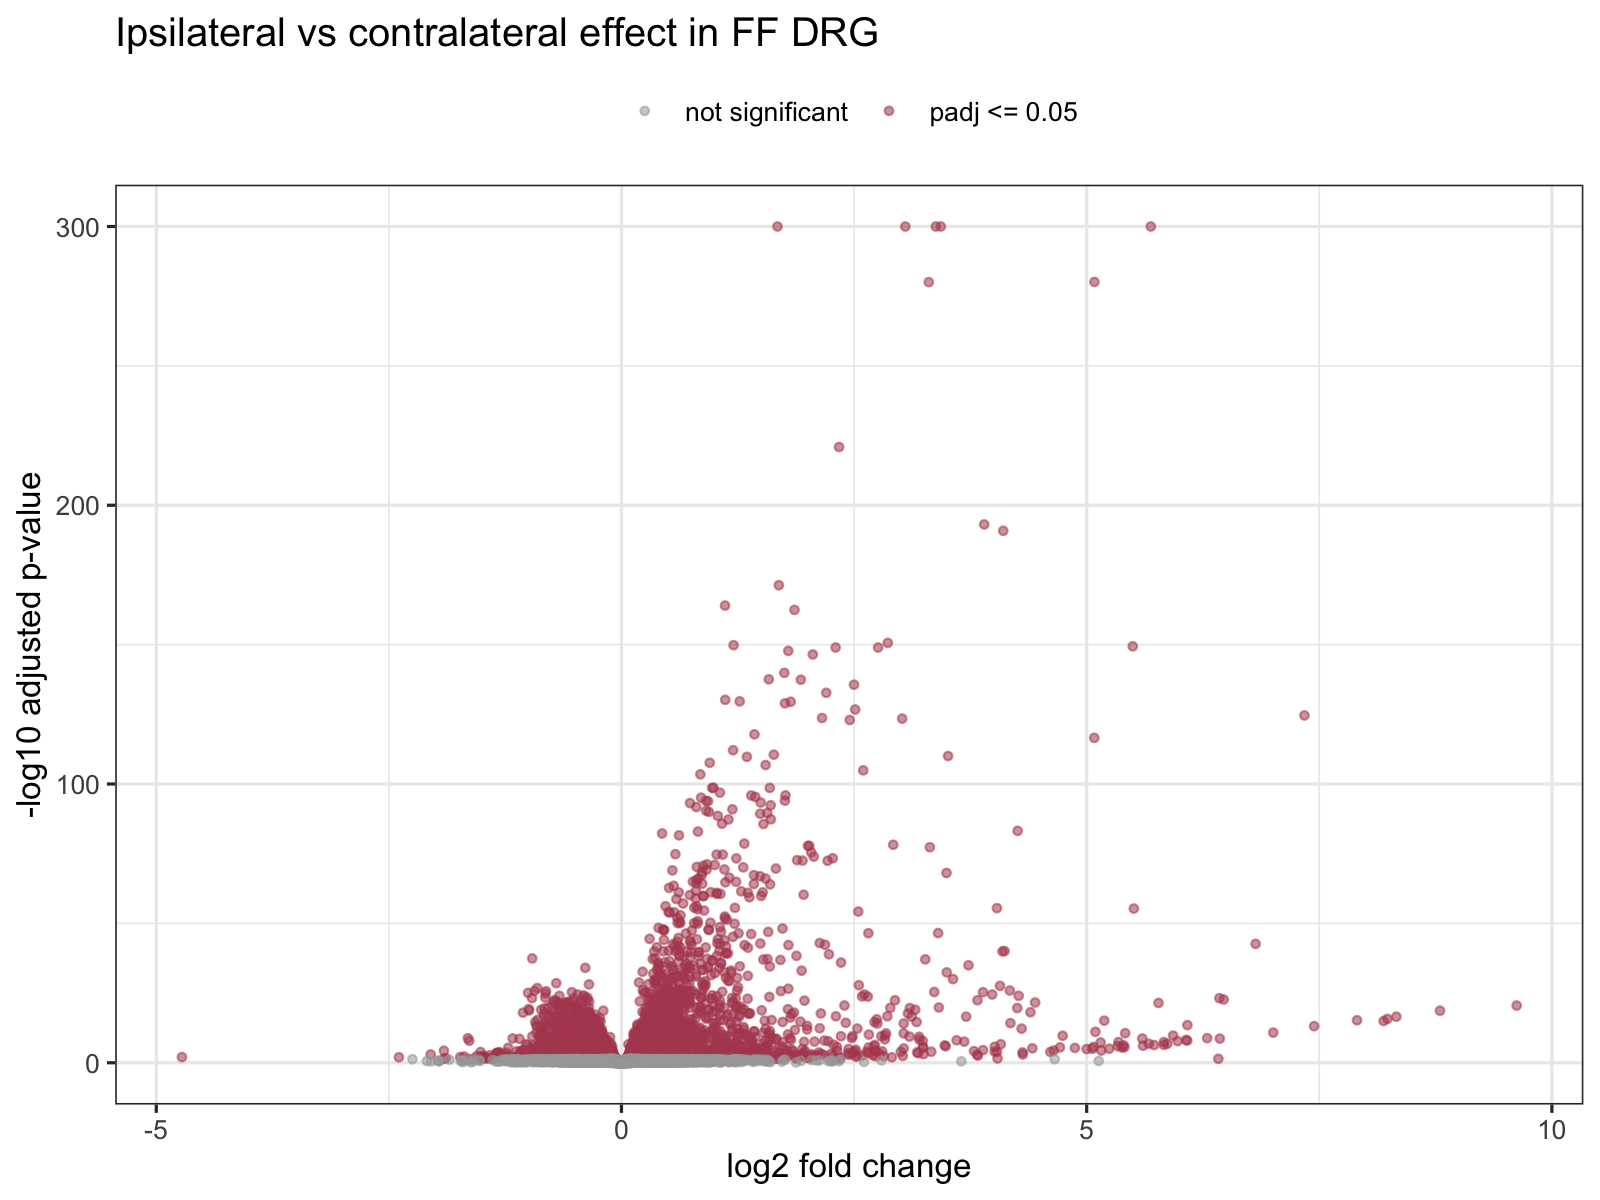
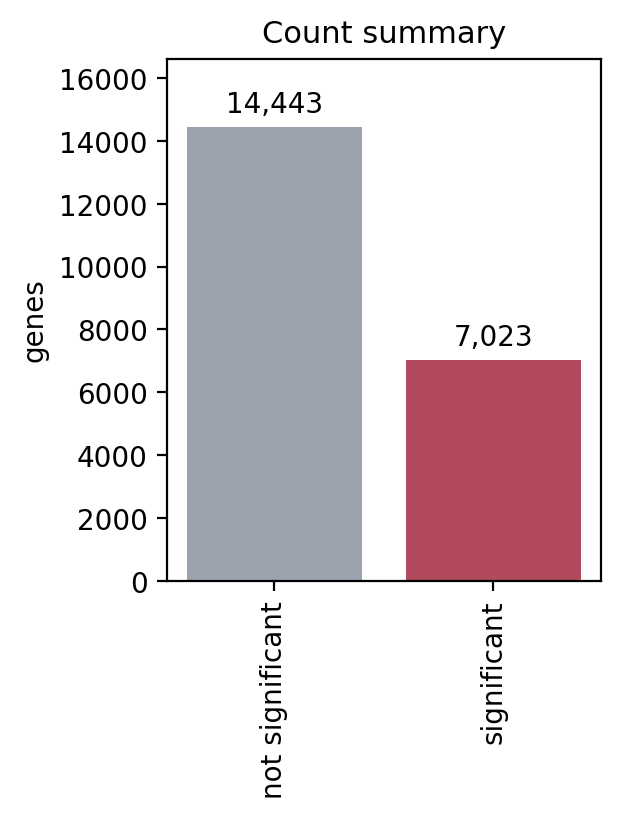

In [19]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for this representative contrast.

**What the output means:** This is the strongest contrast in the notebook. Genes far to the left or right have larger fold changes, and genes higher on the plot have stronger statistical support. The fact that many genes are both far from zero and high on the plot tells us that injury in control tissue drives a large and well-supported expression shift.

**Interpretation:** In this volcano plot, 4,667 genes are significant and 14,221 are not. That is a very large DE signal, and the spread of significant points away from zero shows that this is not just a small statistical effect — it is a broad biological shift. **What this means for the next step:** This should be treated as one of the main headline figures in the notebook and in the report.


## DRG / NovaSeq X / ipsilateral vs contralateral — ipsi_vs_contra_in_cre


### Full result table preview


In [20]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'ipsi_vs_contra_in_cre')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the first rows of the full DE table for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the full results table written by the pipeline for this side-specific contrast and previewed the top rows.

**What the output means:** This table has the same DE columns as the main injury contrast, but here it represents a secondary family. It shows whether side-specific sham differences exist in control tissue and how strong they are at the gene level.

**Interpretation:** This table shows that `ipsi_vs_contra_in_cre` has 52 significant genes out of 19,498 tested. That is a real signal, but it is clearly far smaller than the main tissue injury result. **What this means for the next step:** This table supports keeping the side-specific family in the notebook, but it should stay in a supporting role rather than becoming a main result.


### Significant hits preview


In [21]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the significant-hits table for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the filtered significant results table for this side-specific contrast and previewed the top rows.

**What the output means:** This tells us which genes show statistically supported side-specific differences in control tissue. Even if the signal is smaller than the main injury contrasts, this table shows that the side-specific family still contains interpretable structure.

**Interpretation:** This table isolates the 52 genes that remain significant in the side-specific control comparison. That is enough to show a meaningful side-specific signal, but not enough to compete with the injury contrasts. **What this means for the next step:** These genes can be used as supporting evidence that the side-specific family carries real structure without letting it overshadow the main story.


### Volcano plot



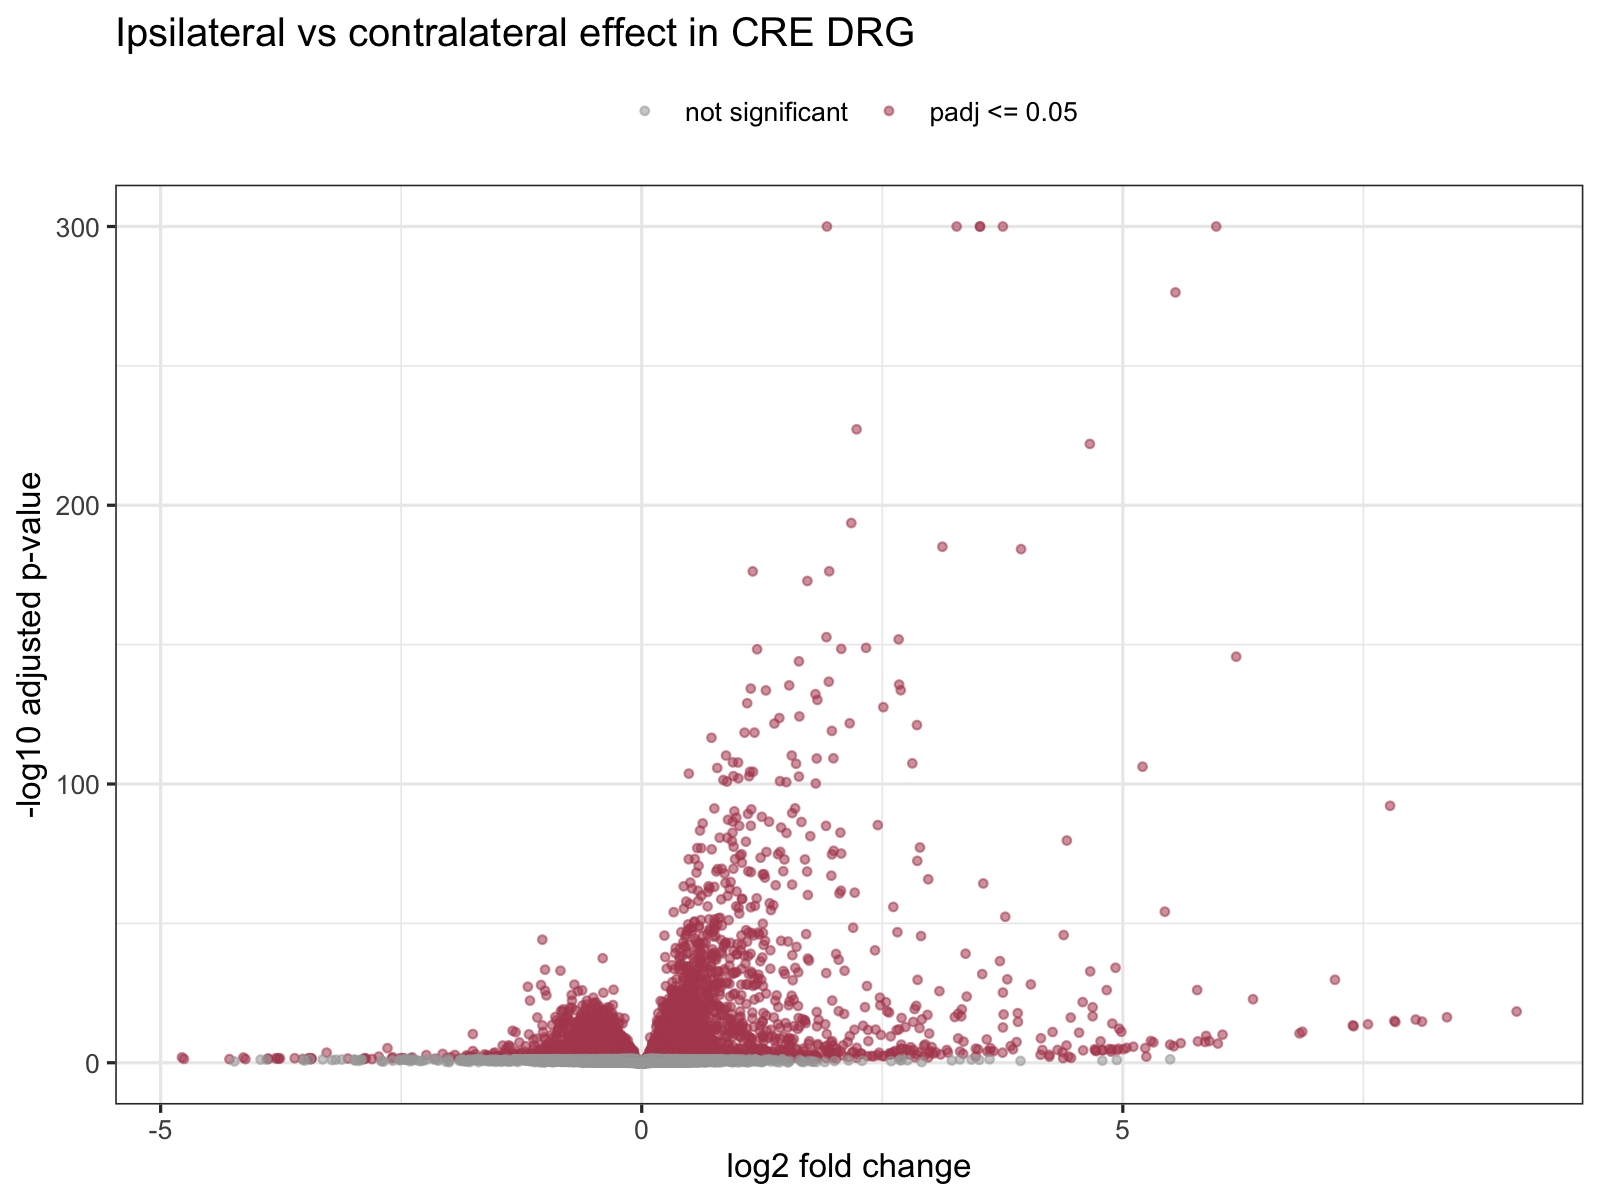
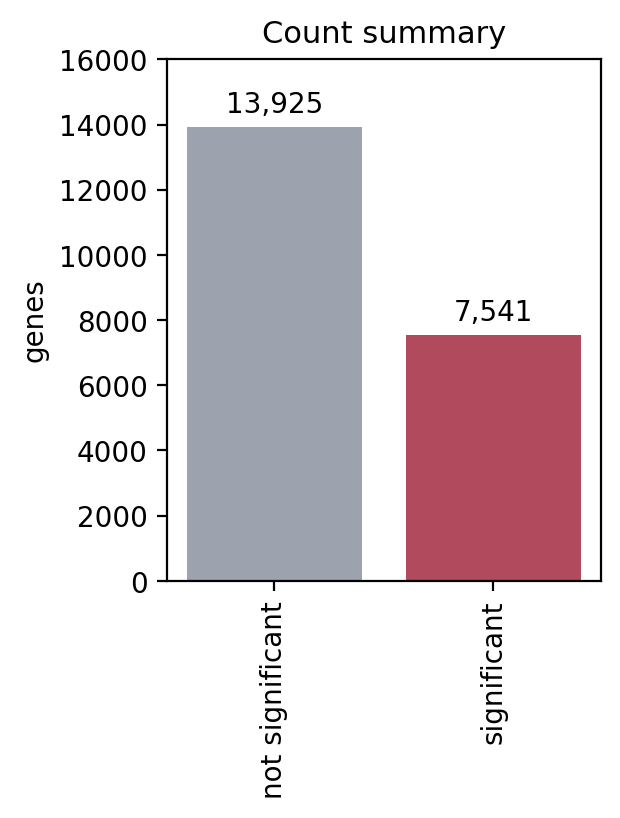

In [22]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for this representative side-specific contrast.

**What the output means:** This is a supporting contrast, not the main story. The plot lets us judge whether the side-specific signal is concentrated in a smaller set of genes and whether that signal is still strong enough to interpret, even though it is weaker than the main tissue injury contrast.

**Interpretation:** In this volcano plot, 52 genes are significant and 19,446 are not. The signal is real but modest, which is exactly what we expect from a secondary side-specific comparison. **What this means for the next step:** This figure is useful to show that the family split preserved interpretable secondary structure, but it should not be presented as the notebook’s central biological finding.


## DRG / NovaSeq X / genotype effect — geno_in_ipsi


### Full result table preview


In [23]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'geno_in_contra')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the first rows of the full DE table for `geno_in_ipsi`.

**How we did it:** Loaded the full results table written by the pipeline for the DRG-family genotype contrast and previewed the top rows.

**What the output means:** This table shows the gene-level DE results for the DRG genotype family. It tells us whether genotype effects are detectable in ipsilateral DRG and how strong those effects are in terms of fold change and adjusted significance.

**Interpretation:** This table shows that `geno_in_ipsi` has 139 significant genes out of 18,985 tested. That is clearly a real result, but it is still much narrower than the main tissue injury contrasts. **What this means for the next step:** This result is strong enough to keep as a supporting analysis and gives us a ranked list if we want one or two DRG-family examples later.


### Significant hits preview


In [24]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the significant-hits table for `geno_in_ipsi`.

**How we did it:** Loaded the filtered significant results table for the DRG-family genotype contrast and previewed the top rows.

**What the output means:** This table isolates the genes that remain significant in the DRG-family genotype comparison. It shows that the DRG genotype family contributes a real DE signal instead of being included only as a formality.

**Interpretation:** This table isolates the 139 significant genes in the DRG-family genotype contrast. That confirms that the DRG genotype family is analytically productive and not just a side note with no signal. **What this means for the next step:** These rows give us a short list if we later want representative DRG-family genes in the write-up.


### Volcano plot



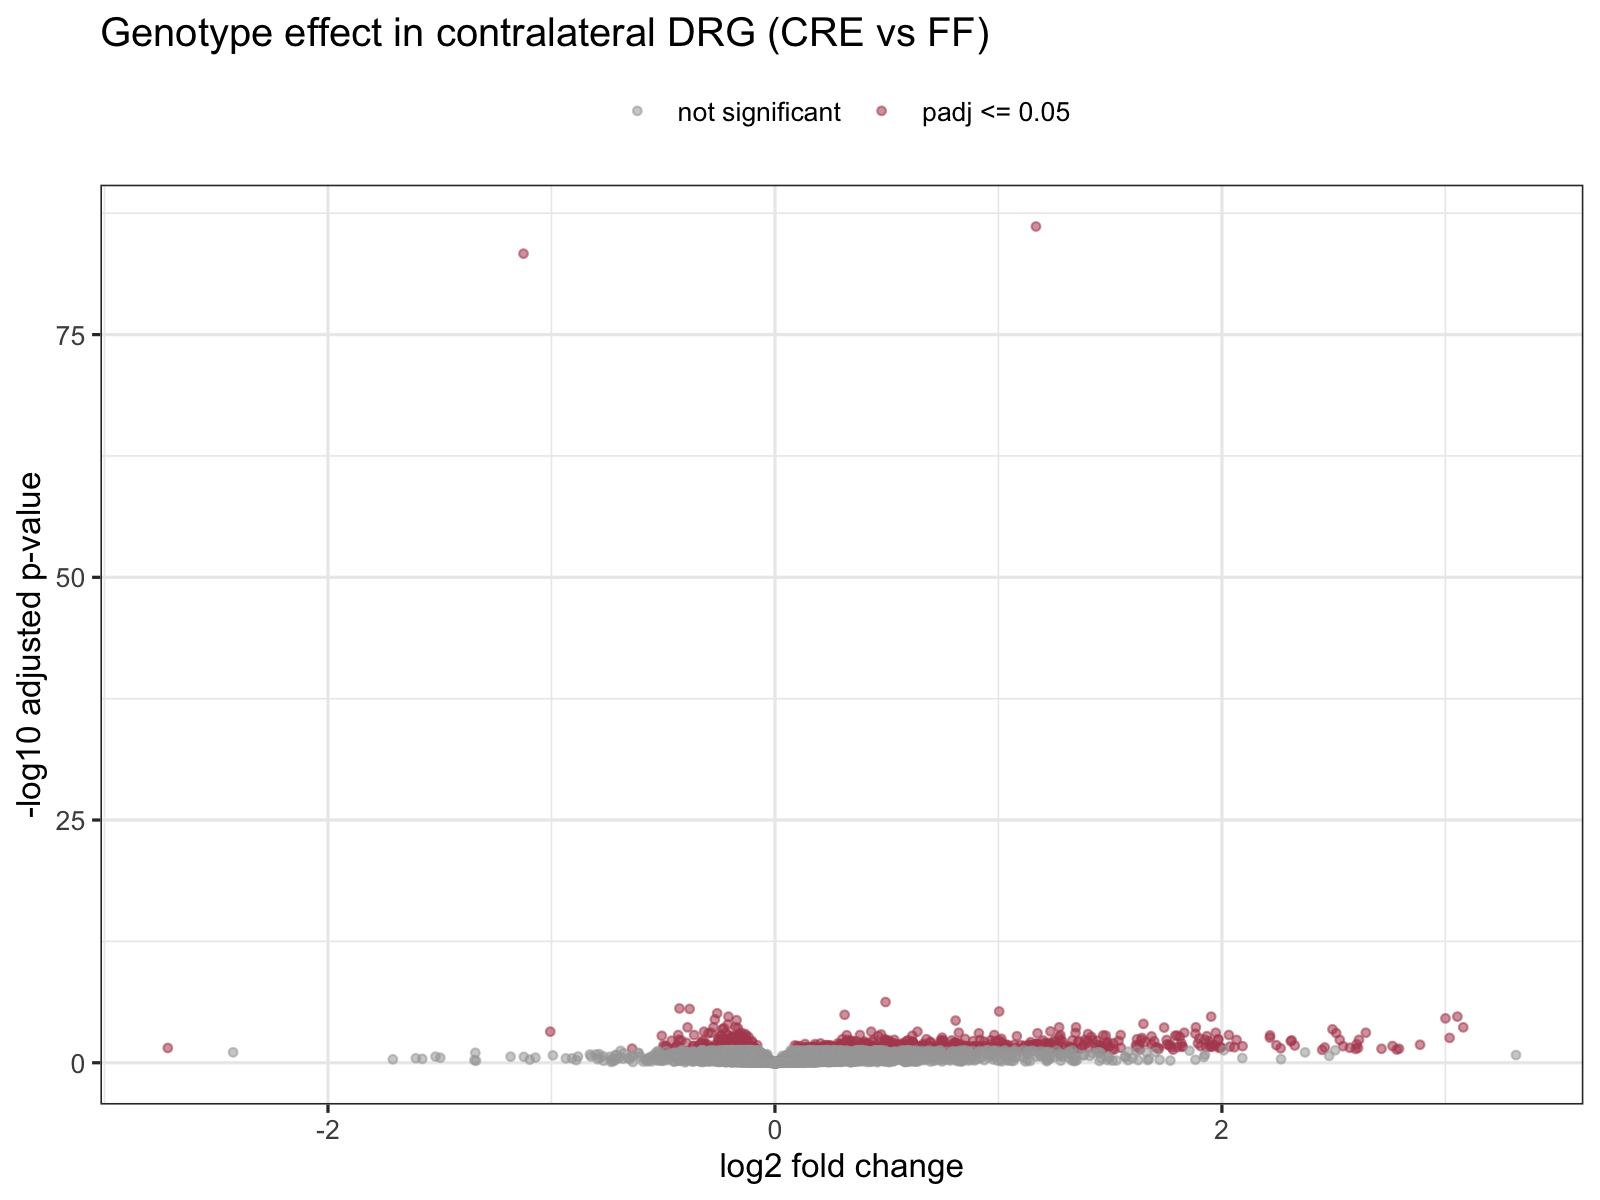
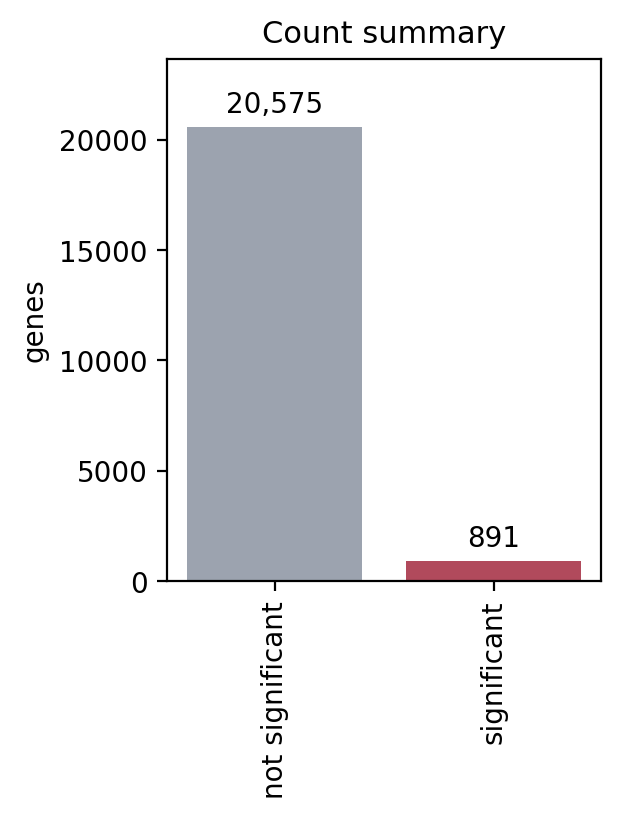

In [25]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `geno_in_ipsi`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for the DRG-family genotype contrast.

**What the output means:** This plot shows whether the DRG-family genotype effect is broad and strong or narrower and more modest. It supports the conclusion that the DRG genotype family produces an interpretable DE result, even if it is not as dominant as the main tissue injury contrasts.

**Interpretation:** In this volcano plot, 139 genes are significant and 18,846 are not. That makes the DRG-family result real but clearly secondary to the much larger tissue injury contrasts. **What this means for the next step:** This plot supports keeping the DRG genotype family in the notebook and possibly in the report, but as a supporting result rather than the central story.


## Shared notebook comparison panels

This section brings in the compact preview panels that also appear in the shared team notebook, so the local notebook has the same quick-read visual summary.


### Main contrast previews

These are the quickest contrast-level plots to show when someone asks where the strongest gene-level differences appear across the `mouse_new` DE package.


In [ ]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_volcano.png'), width=900))
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_heatmap.png'), width=900))
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'geno_in_contra_volcano.png'), width=900))
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'interaction_volcano.png'), width=900))


**What we did:** Displayed the same compact preview plots used in the shared team walkthrough.

**How we did it:** Loaded four saved contrast figures directly from the `family_drg_novaseqx/tables/` output bundle so the strongest and most informative views are visible together.

**What the output means:** This panel gives a fast visual comparison of the main side-specific result, one matching heatmap, a stronger genotype-support contrast, and the small interaction contrast. It is useful when we want a single section that quickly shows which result is dominant and which results are more secondary.


### Top genes preview for the two main side-specific contrasts


In [ ]:
display(pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_top_genes.tsv', sep='\t').head(20))
display(pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_cre_top_genes.tsv', sep='\t').head(20))


**What we did:** Displayed the top-gene previews for the two main side-specific contrasts.

**How we did it:** Loaded the saved `*_top_genes.tsv` tables for `ipsi_vs_contra_in_ff` and `ipsi_vs_contra_in_cre` and previewed the first 20 rows from each.

**What the output means:** These are the quickest tables to use when we want named gene examples from the main paper story. They connect the big contrast-level visuals back to concrete genes that can be discussed in results or figure captions.


## Main takeaways

- The `SRP618841` DE run completed for one balanced DRG family on `NovaSeq X`.
- The strongest visible structure is by side (`ipsi` vs `contra`).
- The main paper path is the side-specific DRG signal, while genotype and interaction remain supporting or secondary.
- The shared output tree on `sequoia` is:
  - `/home/zebrafish/mouse/SRP618841_parallel/differential_expression_all20`
